In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import pylab as plt
import glob
import os
import shutil
from pprint import pprint
import zipfile

In [14]:
import stephane.display.graphes as graphes
import stephane.tools.Smath as smath


import icewave.phone.analyse as analyse

import scipy.signal as sig

Linux
adour


In [65]:
date = '2025_1023'
year,day = date.split('_')

base = f'/media/turbots/DATA/thiou/labshared2/Projet_E/Data/{date}/'
datafolder = base + 'FP4_00/'
savefolder = base+ 'Results/'
if not os.path.exists(savefolder):
    os.makedirs(savefolder)

filelist = glob.glob(datafolder+'*.csv')
pprint(filelist)

['/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.gyroscope-10-774358033955-775247068989.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.gyroscope-13-777025202611-777914268028.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-9-773554389859-774454379859.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-4-769054389861-769954379860.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.gyroscope-2-767243688439-768133058196.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data/2025_1023/FP4_00/P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-10-774454389859-775354379858.csv',
 '/media/turbots/DATA/thiou/labshared2/Projet_E/Data

In [67]:
datafiles = glob.glob(datafolder+'/*.csv')
#pprint(datafiles)

'10'

In [72]:
import icewave.tools.rw_data as rw

datefmt = '23T13_30_57-'

datas = {}
for i,filename in enumerate(datafiles):
    typ = filename.split('/')[-1].split(datefmt)[1].split('-')[0]

    key = int(filename.split('/')[-1].split(datefmt)[1].split('-')[1])
    print(key,typ,os.path.basename(filename))
    if not typ=='gps':
        data = load_phone.load_gobfile(filename)
    #    data = rw.read_csv(filename)
        if key in datas.keys():
            datas[key].update(data)
        else:
            datas[key] = data

10 android.sensor.gyroscope P101_D2025-10-23T13_30_57-android.sensor.gyroscope-10-774358033955-775247068989.csv
13 android.sensor.gyroscope P101_D2025-10-23T13_30_57-android.sensor.gyroscope-13-777025202611-777914268028.csv
9 android.sensor.magnetic_field P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-9-773554389859-774454379859.csv
4 android.sensor.magnetic_field P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-4-769054389861-769954379860.csv
2 android.sensor.gyroscope P101_D2025-10-23T13_30_57-android.sensor.gyroscope-2-767243688439-768133058196.csv
10 android.sensor.magnetic_field P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-10-774454389859-775354379858.csv
2 gps P101_D2025-10-23T13_30_57-gps-2-767970151841-768869151841.csv
2 android.sensor.magnetic_field P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-2-767254389862-768154379861.csv
12 android.sensor.magnetic_field P101_D2025-10-23T13_30_57-android.sensor.magnetic_field-12-776254389858-77715437985

In [75]:
datas[11].keys()

dict_keys(['coords', 'tm', 'mx', 'my', 'mz', 'tg', 'gx', 'gy', 'gz', 'ta', 'ax', 'ay', 'az'])

7


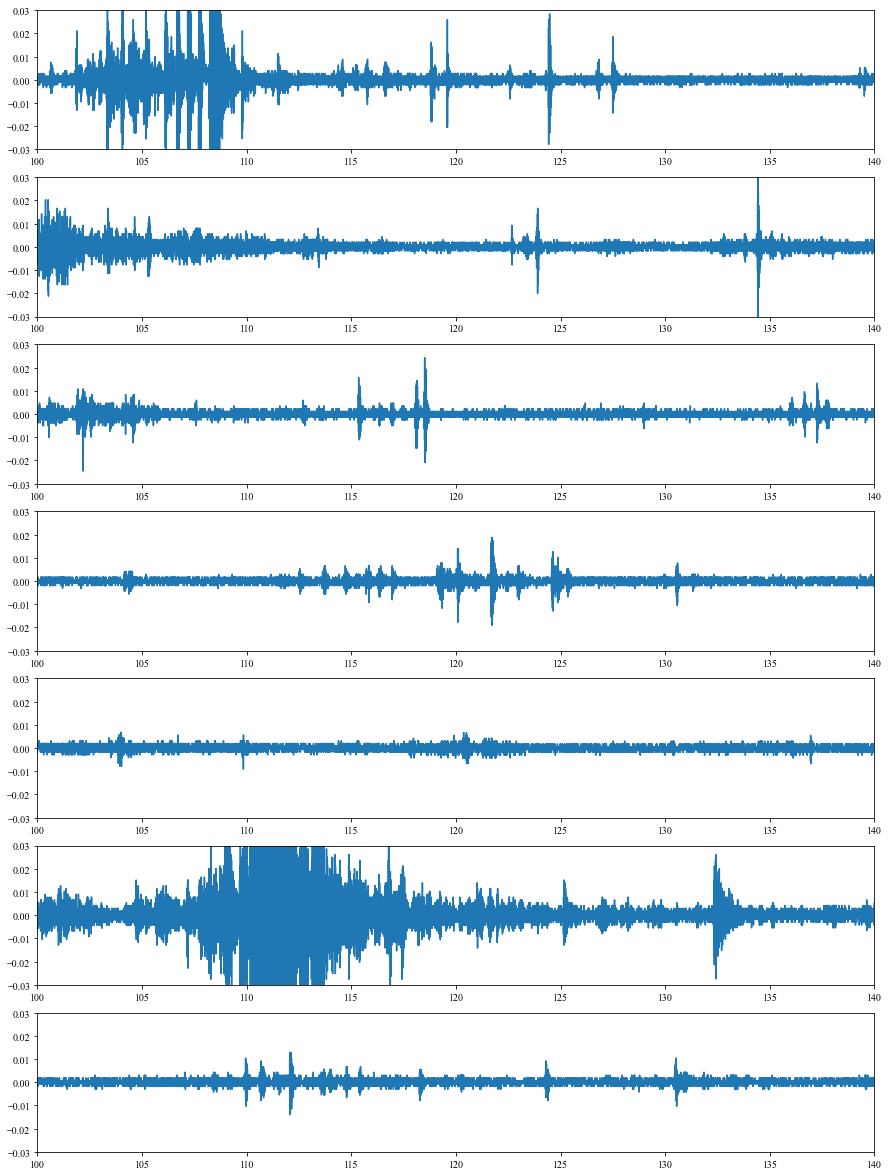

In [80]:
n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,3*n),nrows=n)
var = 'g'
for i,(key,ax) in enumerate(zip(range(n0+1,n0+n+1),axs)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6
    c = 'y'
#    for c in data['coords']:
    y = data[var+c]
    y = y-np.mean(y)
    ax.plot(t,y)

    ax.set_ylim([-0.03,0.03])
    ax.set_xlim([100,140])

7


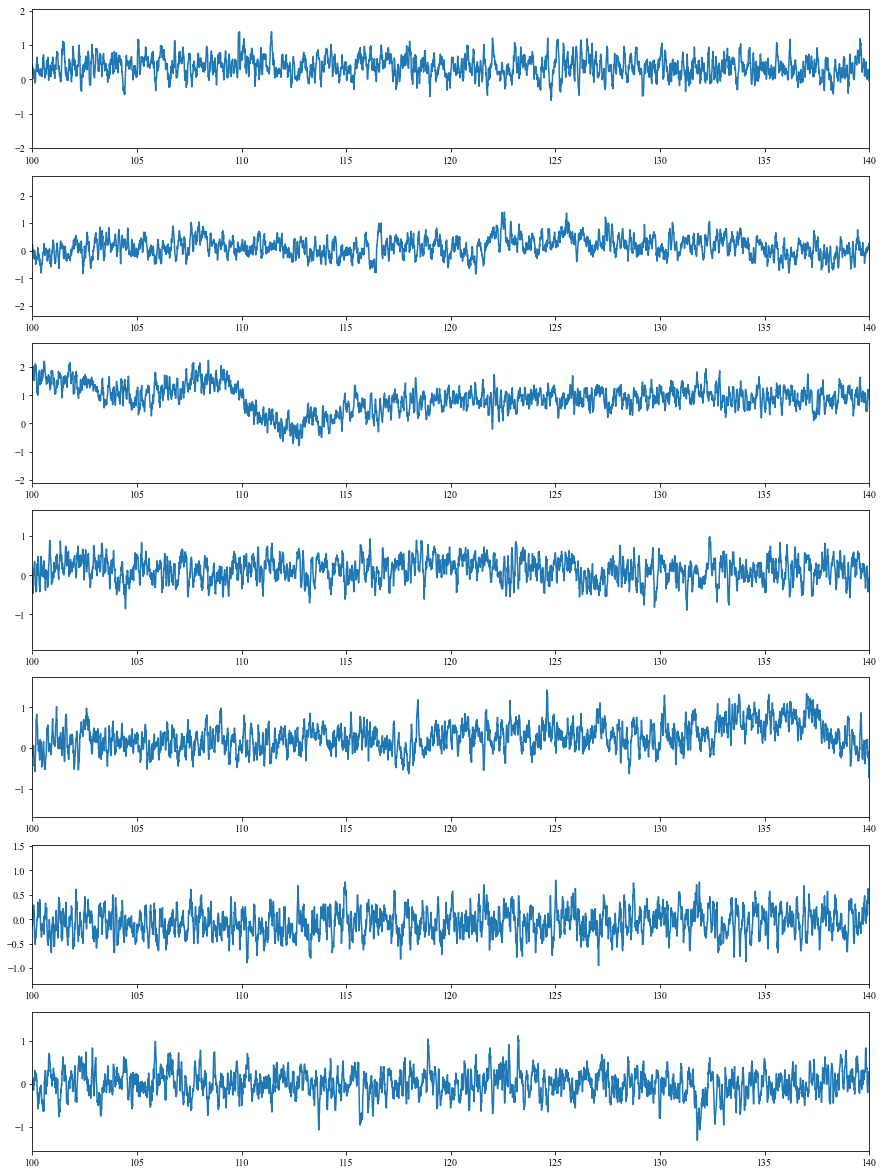

In [82]:
n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,3*n),nrows=n)
var = 'm'
for i,(key,ax) in enumerate(zip(range(n0+1,n0+n+1),axs)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6
    c = 'y'
#    for c in data['coords']:
    y = data[var+c]
    y = y-np.mean(y)
    ax.plot(t,y)

    #ax.set_ylim([-0.03,0.03])
    ax.set_xlim([100,140])

7
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18


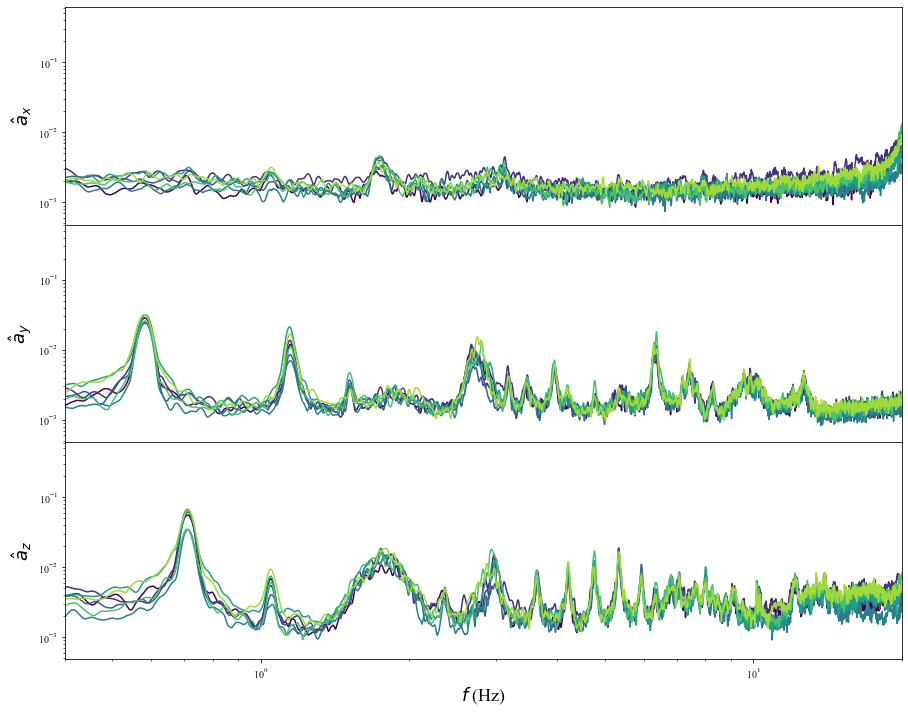

In [64]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'a'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=20000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
    #    ax.set_ylim([-0.3,0.3])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
graphes.save_figs(figs,savedir=savefolder,prefix='FP_00_Spectrum_3C')


       

7
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18
Number of samples : 18


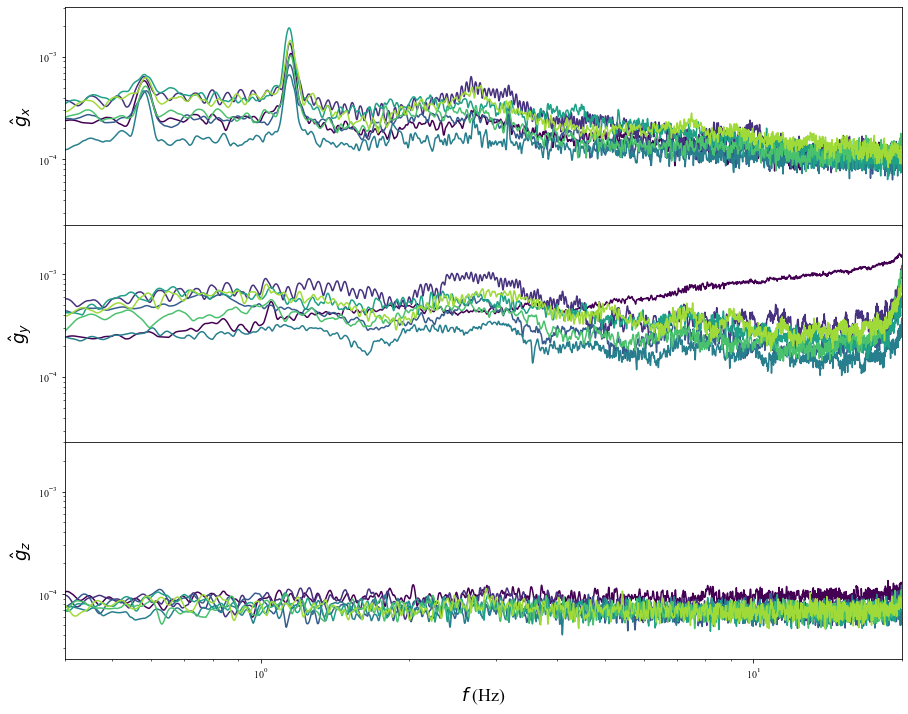

In [89]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'g'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=20000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
        #ax.set_ylim([0.05,0.5])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
#graphes.save_figs(figs,savedir=savefolder,prefix='FP_00_Spectrum_3C')


       

7
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17
Number of samples : 17


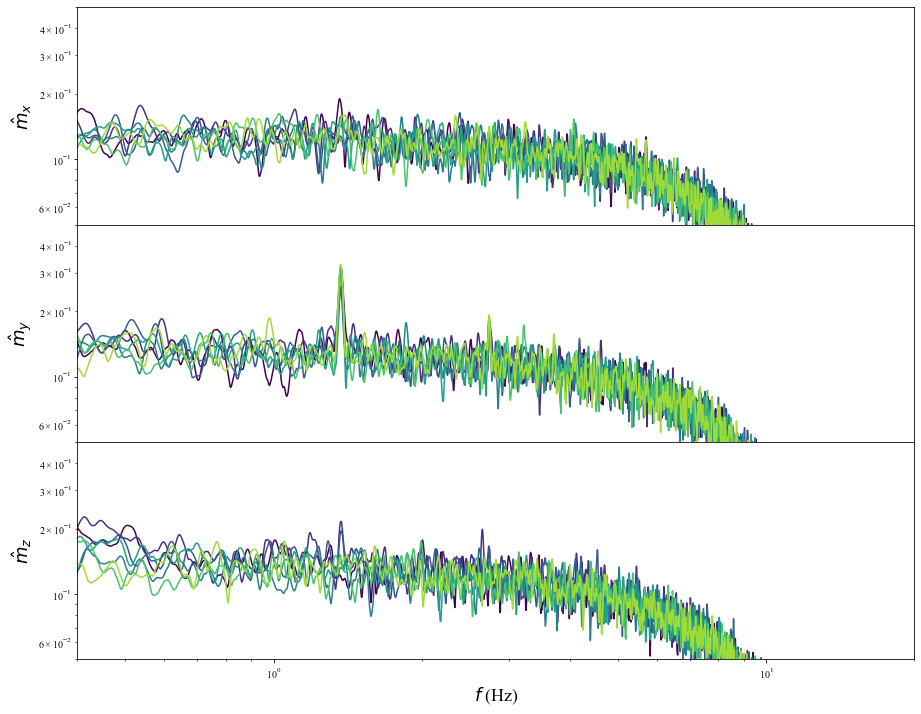

In [87]:
import icewave.phone.analyse as analyse
import matplotlib as mpl

n0 = 6
n = len(datas.keys())-n0
print(n)
fig,axs = plt.subplots(figsize=(15,4*3),nrows=3,sharex=True,sharey=True)
var = 'm'


cmap = mpl.colors.Colormap('viridis')

def colorrr(n):
    colors = plt.cm.viridis(np.linspace(0,1,256))
    return colors[n]

for i,key in enumerate(range(n0+1,n0+n+1)):
    data = datas[key]
    t = data['t'+var]
    t = (t-t[0])/10**6

    for c,ax in zip(data['coords'],axs):
        y = data[var+c]
        y = y-np.mean(y)
    
        f,TFmoy,fmax,Amax = analyse.time_spectrum(t,y,nt=5000)
    #    for c in data['coords']:
        color = colorrr(int(i/n*256))
        ax.loglog(f,TFmoy,color=color)
    
        ax.set_ylim([0.05,0.5])
        ax.set_xlim([0.4,20])
    
        figs = graphes.legende('',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=ax)

plt.subplots_adjust(hspace=0)

figs = graphes.legende('$f$ (Hz)',r'$\hat '+str(var)+'_'+str(c)+'$','',ax=axs[2])
#graphes.save_figs(figs,savedir=savefolder,prefix='FP_00_Spectrum_3C')


       

a
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Accelerometer.csv
g
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Gyroscope.csv
l
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Location.csv
m
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0226/T_0001_04_AGML/Magnetometer.csv


In [13]:
print(data.keys())

dict_keys(['gy', 'gx', 'gz', 'tg', 'ay', 'ax', 'az', 'ta', 'my', 'mx', 'mz', 'tm', 'loc'])


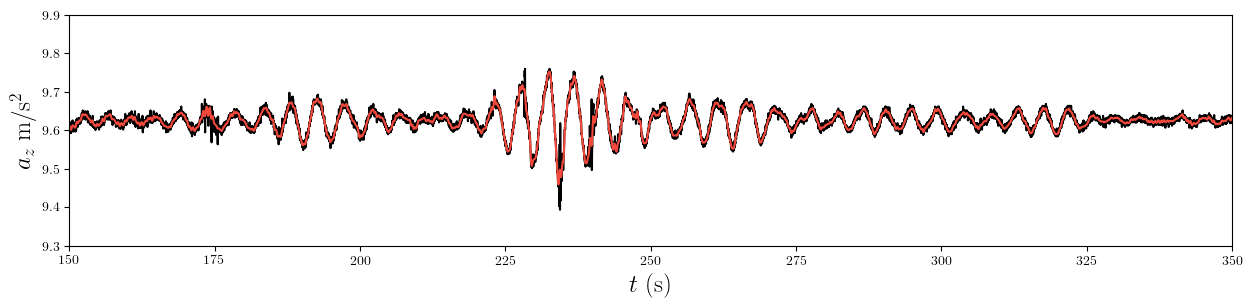

In [46]:
plt.subplots(figsize=(15,3))
#data['a']
plt.plot(data['ta'],data['az'],'k')
plt.xlim([150,350])
plt.ylim([9.3,9.9])
figs = graphes.legende('$t$ (s)','$a_z$ m/s$^2$','')


[b,a] = sig.butter(6,0.1,'low')
az_f =  sig.filtfilt(b,a,data['az'])


'#F4AD3C'
plt.plot(data['ta'],az_f,color=(244/256,73/256,60/256))

graphes.save_figs(figs,savedir=savefolder,overwrite=True)

dict_keys(['a', 'g', 'l', 'm'])
['0.0' '0.0' '0.1940502822' ... '0.0' '0.0' '0.0']


(9.25, 10.5)

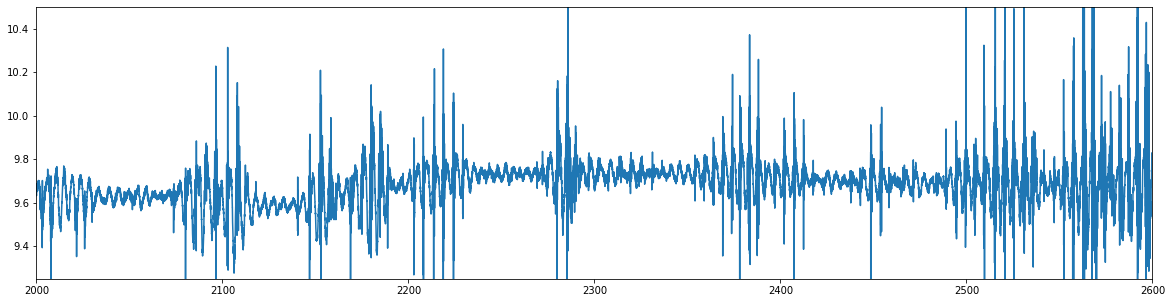

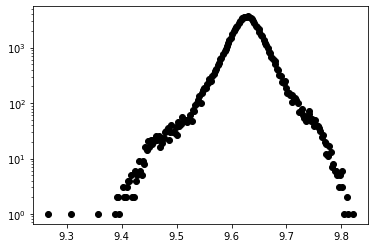

In [79]:
[n,x] = np.histogram(data['a']['d'][:,3][5000:100000],500)

xc = (x[1:]+x[:-1])/2

plt.plot(xc-x0,n,'ko')
plt.yscale('log')


In [12]:
folderlist = glob.glob(folder+'/*/')

data = {}
for fold in folderlist:
    print(fold)
    d,key = phone.read_data(fold)

/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_01_Accelero_Gyro_Magneto_GPS 2024-02-10_19-10-30/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_04_192_168_0_104/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_06_Accelero_Gyro_Magneto_GPS 2024-02-10_18-55-25/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_07_Accelero_Gyro_Magneto_GPS 2022-04-10_11-00-32/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_08_Accelero_Gyro_Magneto_GPS 2024-02-10_18-38-02/
/Users/stephane/Documents/git/icewave/icewave/field/Bicwin2024/Data/2024/0210/Telephones/Sag24_S101_2024_0210/0000_09_Accelero_Gyro_Magneto_GPS 2024-02-10_18-40-35/
/Users/stephane/Documents/git/icewave/icew